In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

2026-03-17 00:46:27.040179: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
img_size = (224,224)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/home/sudhanshu-gill/Downloads/archive/brain_tumor_dataset",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/home/sudhanshu-gill/Downloads/archive/brain_tumor_dataset",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)

Found 253 files belonging to 2 classes.
Found 253 files belonging to 2 classes.


2026-03-17 00:46:39.497747: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y:(normalization_layer(x),y))
test_ds = test_ds.map(lambda x,y:(normalization_layer(x),y))

In [5]:
model = keras.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1,activation='sigmoid')
])

/home/sudhanshu-gill/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-17 00:46:39.888943: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 44302336 exceeds 10% of free system memory.
2026-03-17 00:46:39.966593: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 44302336 exceeds 10% of free system memory.
2026-03-17 00:46:40.000613: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 44302336 exceeds 10% of free system memory.


In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5  
)

Epoch 1/5


2026-03-17 00:46:41.672218: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 44302336 exceeds 10% of free system memory.
2026-03-17 00:46:42.802422: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 19267584 exceeds 10% of free system memory.


8/8 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.6680 - loss: 0.7457 - val_accuracy: 0.7866 - val_loss: 0.5255
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.8024 - loss: 0.5203 - val_accuracy: 0.8103 - val_loss: 0.4353
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7984 - loss: 0.4341 - val_accuracy: 0.8379 - val_loss: 0.3767
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step - accuracy: 0.8419 - loss: 0.3764 - val_accuracy: 0.8854 - val_loss: 0.2825
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.8775 - loss: 0.2919 - val_accuracy: 0.8854 - val_loss: 0.2314


In [9]:
img = keras.preprocessing.image.load_img(
    "/home/sudhanshu-gill/Downloads/archive/brain_tumor_dataset/no/22 no.jpg", 
    target_size=(224,224)
)

img_array = keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array,axis=0)/255

prediction = model.predict(img_array)

if prediction > 0.5:
    print("Tumor Detected")
else:
    print("No Tumor")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
Tumor Detected


In [15]:
# force model to build
_ = model(img_array)

/home/sudhanshu-gill/anaconda3/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


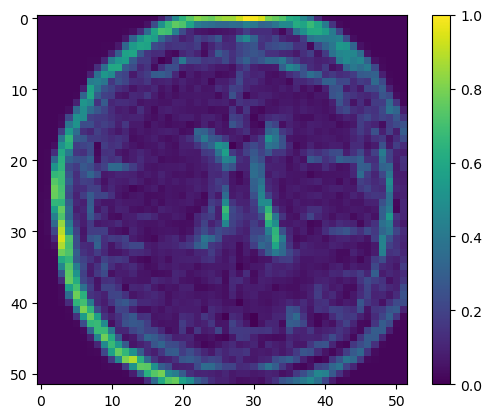

In [16]:
# get last convolution layer
last_conv_layer = model.layers[4]

# create grad model
grad_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=[last_conv_layer.output, model.layers[-1].output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, 0]

# gradients
grads = tape.gradient(loss, conv_outputs)

# average gradients
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]

# weight feature maps
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# normalize
heatmap = tf.maximum(heatmap,0) / tf.reduce_max(heatmap)

# display
plt.imshow(heatmap)
plt.colorbar()
plt.show()

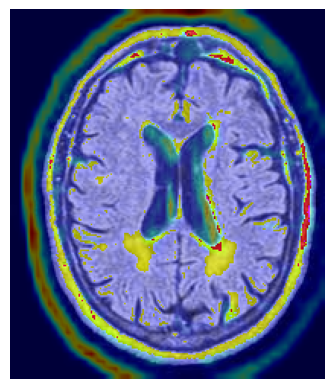

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# CHANGE HERE → same test image path jo prediction me use ki thi
img_path = "/home/sudhanshu-gill/Downloads/archive/brain_tumor_dataset/no/22 no.jpg"

img = cv2.imread(img_path)

# resize heatmap
heatmap = cv2.resize(heatmap.numpy(), (img.shape[1], img.shape[0]))

# convert to 0-255
heatmap = np.uint8(255 * heatmap)

# apply color map
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# overlay heatmap
superimposed = heatmap * 0.4 + img

# display
plt.imshow(cv2.cvtColor(superimposed.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()